# From Raw Data to a Boardroom Decision

**The scenario:** You have just joined **Aurum Capital Advisors** as a junior data analyst. The firm's AI research team has built a model that studies the gold market and predicts whether the price will rise or fall the next day. The model works — but right now it is just numbers in a dataframe. Nobody on the Investment Committee (the firm's "generals," in the language of the lecture) can act on a probability score buried in a notebook.


|---|---|
| AI-Driven Analytics & the AI-Decision Gap | Build a small AI model and feel *why* its raw output isn't enough |
| Visualization across the ML lifecycle | Data Collection → EDA → Model Training → Model Evaluation → Deployment |
| OCAR storytelling | Turn a price chart into a story with an Opening, Challenge, Action, and Resolution |
| Decluttering & small multiples | Fix a chart that tries to say too much at once |
| Isotype graphs | Make a number memorable using scaled icons |
| Explainable AI (XAI) | Show *why* the model made its prediction, not just *what* it predicted |


## Setup
Load the libraries and the dataset. This is the *Raw Data* box at the very start of the AI analytics pipeline from lecture.

In [5]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/anushreex30/gold-dataset-synthetic/gold_price_2000_2026.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score

# A consistent visual identity for the whole notebook - Aurum Capital's colors
GOLD = "#d4af37"
CHARCOAL = "#333333"
BLUE = "#3b6ea5"
RED = "#b5432e"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("/kaggle/input/datasets/anushreex30/gold-dataset-synthetic/gold_price_2000_2026.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,Open,High,Low,Price_USD,Volume,USD_Index,Inflation_Rate,Interest_Rate
0,2000-01-03,280.18,281.00,279.19,280.19,107168,120.00,2.64,3.94
1,2000-01-04,280.88,281.21,278.73,280.14,135551,119.50,1.78,3.98
2,2000-01-05,281.19,281.94,280.48,280.79,78081,116.92,2.78,3.66
3,2000-01-06,283.43,284.20,280.43,282.21,103527,113.81,2.50,3.83
4,2000-01-07,281.68,283.12,281.11,282.07,93135,119.40,2.12,3.66


## Stage 1 — Data Collection: *"Can I trust this data?"*

The raw file looks complete at first glance. But it only contains *trading days*. If we lay it against every calendar day, weekends and holidays will show up as gaps. Seeing that gap pattern is exactly the kind of visual data-quality check the Investment Committee expects an analyst to have already done.

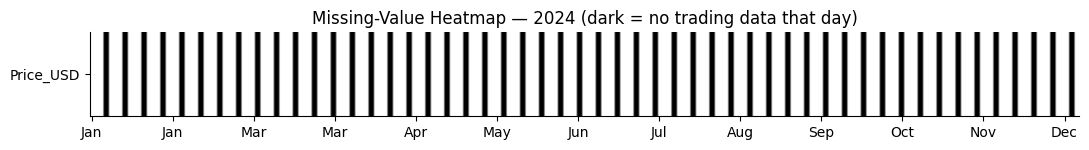

Trading days on file: 6,933
Calendar days in range: 9,705
Non-trading days (weekends/holidays): 2,772


In [8]:
# Reindex onto every calendar day to reveal where data is naturally absent (weekends/holidays)
full_range = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
calendar_view = df.set_index("Date").reindex(full_range)

# Take one representative year so the gap pattern is actually visible
one_year = calendar_view.loc["2024"]
missing_matrix = one_year[["Price_USD"]].isna().T.astype(int)

fig, ax = plt.subplots(figsize=(11, 1.6))
ax.imshow(missing_matrix, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax.set_yticks([0]); ax.set_yticklabels(["Price_USD"])
ax.set_xticks(range(0, len(one_year), 30))
ax.set_xticklabels([d.strftime("%b") for d in one_year.index[::30]])
ax.set_title("Missing-Value Heatmap — 2024 (dark = no trading data that day)")
plt.tight_layout()
plt.show()

print(f"Trading days on file: {len(df):,}")
print(f"Calendar days in range: {len(calendar_view):,}")
print(f"Non-trading days (weekends/holidays): {calendar_view['Price_USD'].isna().sum():,}")

Missing Data- Heatmaps

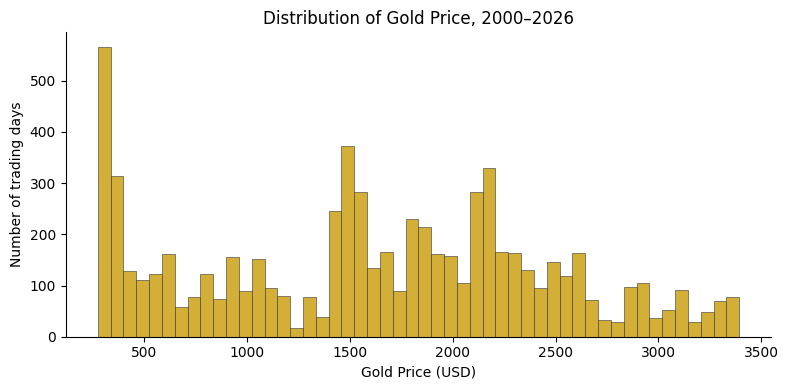

In [9]:
# to histogram assess quality/shape of the core variable before modeling
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["Price_USD"], bins=50, color=GOLD, edgecolor=CHARCOAL, linewidth=0.4)
ax.set_xlabel("Gold Price (USD)")
ax.set_ylabel("Number of trading days")
ax.set_title("Distribution of Gold Price, 2000–2026")
plt.tight_layout()
plt.show()

**Reading the output:** the gaps are exactly the calendar's weekends and holidays — that's *expected* missingness, not a data-quality bug, so we can proceed with confidence. The histogram is heavily right-skewed: gold spent most of the last 26 years under \$1,500, with a long tail out past \$3,000 in recent years. That skew matters for every chart we build next — a naive linear axis will crush two decades of history into the bottom-left corner.

## Stage 2 — Exploratory Analysis: *"What patterns live in this data?"*
Lecture's table pairs this stage with **scatter plots** and **box plots**, for the purpose of **discovering patterns**. We're looking for the raw relationships our AI model will later try to exploit.

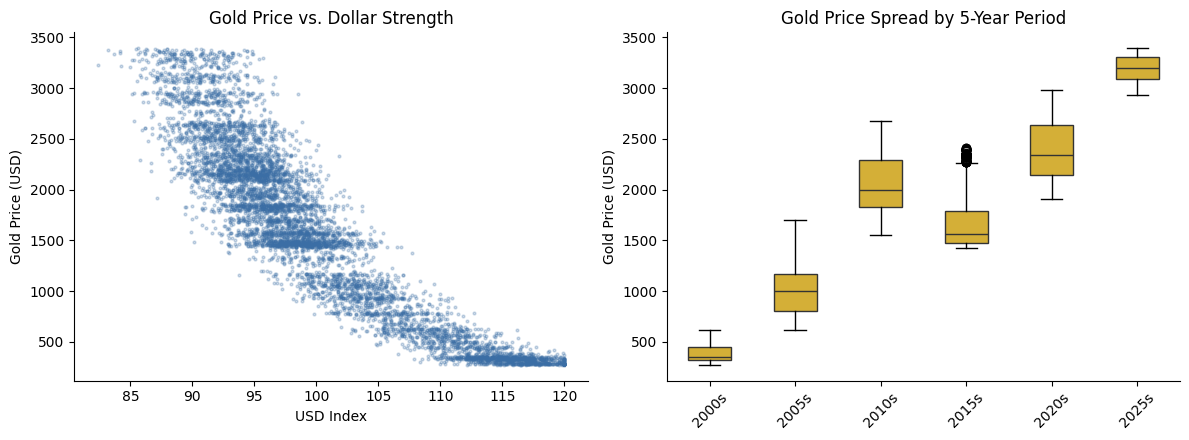

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(df["USD_Index"], df["Price_USD"], s=4, alpha=0.25, color=BLUE)
axes[0].set_xlabel("USD Index"); axes[0].set_ylabel("Gold Price (USD)")
axes[0].set_title("Gold Price vs. Dollar Strength")

period = (df["Date"].dt.year // 5) * 5
df["_period"] = period.astype(str) + "s"
order = sorted(df["_period"].unique())
axes[1].boxplot([df.loc[df["_period"] == p, "Price_USD"] for p in order],
                 tick_labels=order, patch_artist=True,
                 boxprops=dict(facecolor=GOLD, edgecolor=CHARCOAL),
                 medianprops=dict(color=CHARCOAL))
axes[1].set_ylabel("Gold Price (USD)")
axes[1].set_title("Gold Price Spread by 5-Year Period")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Pattern spotted:** gold price falls as the USD Index rises — a classic inverse relationship, since gold is priced in dollars. The box plots show something an AI model would also learn: not just that price has trended up decade over decade, but that *volatility* (box height) has grown too. Both observations become candidate features for our model.


| Feature          | What it tells you                 | Example from your graph         |
| ---------------- | --------------------------------- | ------------------------------- |
| Median           | Typical value                     | Gold price increased over time  |
| Box (IQR)        | Variability of the middle 50%     | 2020s show high variability     |
| Whiskers         | Normal minimum and maximum values | 2025s have a high overall range |
| Outliers         | Unusual observations              | High-price outliers in 2015s    |
| Skewness         | Whether the data is symmetric     | 2010s slightly right-skewed     |
| Group comparison | Compare distributions             | Prices rise from 2000s to 2025s |


The box plot not only identifies outliers but also summarizes the distribution of gold prices by showing the median, variability (IQR), range, skewness, and allows easy comparison of price trends across different 5-year periods.


## Building the AI Model — and Meeting the "AI-Decision Gap"
Now we do what the lecture calls **AI-driven analytics**: let an algorithm discover a relationship in a high-dimensional space (price momentum, volatility, USD strength, inflation, interest rates, volume) that's too complex to eyeball.

We'll train a simple model to predict **whether tomorrow's gold price will be higher than today's** — a binary Up/Down call the Investment Committee could actually act on.

In [11]:
# Feature engineering
df["Price_Change"] = df["Price_USD"].pct_change()
df["Volatility"] = (df["High"] - df["Low"]) / df["Low"]
df["Target_Up"] = (df["Price_USD"].shift(-1) > df["Price_USD"]).astype(int)

feat_cols = ["Price_Change", "Volatility", "USD_Index", "Inflation_Rate", "Interest_Rate", "Volume"]
model_df = df.dropna(subset=feat_cols + ["Target_Up"]).copy()

X = model_df[feat_cols].values
y = model_df["Target_Up"].values

# Chronological split - never let a model "see the future" when trading is involved
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

mu, sigma = X_train.mean(axis=0), X_train.std(axis=0)
X_train_s = (X_train - mu) / sigma
X_test_s = (X_test - mu) / sigma

print(f"Training on {len(X_train):,} days, testing on {len(X_test):,} days")
print(f"Baseline (always predict 'Up'): {y_test.mean():.1%} of test days actually went up")

Training on 5,545 days, testing on 1,387 days
Baseline (always predict 'Up'): 53.2% of test days actually went up


### Stage 3 — Model Training: *"Is it actually learning?"*
Lecture's table pairs this stage with **Loss Curves**, for **monitoring learning**. Rather than hide the training loop inside a library call, we write the gradient descent ourselves — a handful of lines — precisely so the loss curve below is real, not decorative.

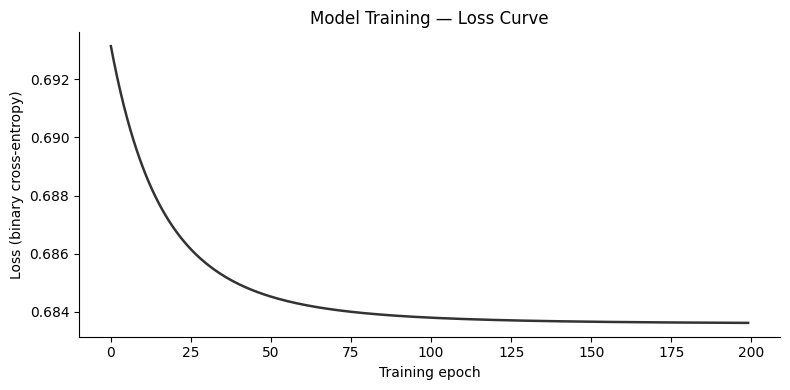

Loss fell from 0.6931 to 0.6836 over 200 epochs


In [13]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

n_features = X_train_s.shape[1]
w, b = np.zeros(n_features), 0.0
lr, epochs = 0.1, 200
losses = []

for _ in range(epochs):
    p = sigmoid(X_train_s @ w + b)
    loss = -np.mean(y_train * np.log(p + 1e-9) + (1 - y_train) * np.log(1 - p + 1e-9))
    losses.append(loss)
    w -= lr * (X_train_s.T @ (p - y_train)) / len(y_train)
    b -= lr * np.mean(p - y_train)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, color=CHARCOAL, linewidth=1.8)
ax.set_xlabel("Training epoch"); ax.set_ylabel("Loss (binary cross-entropy)")
ax.set_title("Model Training — Loss Curve")
plt.tight_layout()
plt.show()

print(f"Loss fell from {losses[0]:.4f} to {losses[-1]:.4f} over {epochs} epochs")

### Stage 4 — Model Evaluation: *"How good is 'good'?"*
Lecture pairs this stage with the **Confusion Matrix** and **ROC Curve**, for the purpose of **measuring performance**.

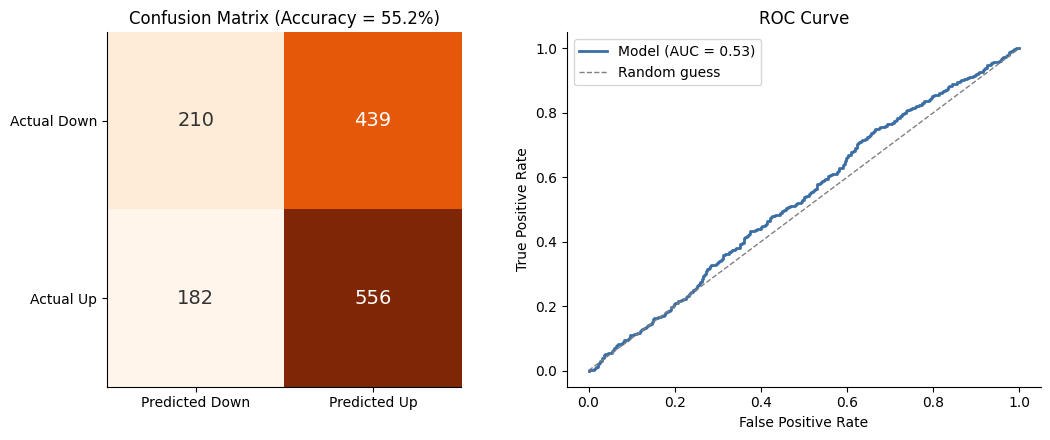

In [14]:
p_test = sigmoid(X_test_s @ w + b)
pred_test = (p_test >= 0.5).astype(int)
acc = accuracy_score(y_test, pred_test)
cm = confusion_matrix(y_test, pred_test)
fpr, tpr, _ = roc_curve(y_test, p_test)
model_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im = axes[0].imshow(cm, cmap="Oranges")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Predicted Down", "Predicted Up"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["Actual Down", "Actual Up"])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=14,
                      color="white" if cm[i, j] > cm.max() / 2 else CHARCOAL)
axes[0].set_title(f"Confusion Matrix (Accuracy = {acc:.1%})")

axes[1].plot(fpr, tpr, color=BLUE, linewidth=2, label=f"Model (AUC = {model_auc:.2f})")
axes[1].plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1, label="Random guess")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

**This is the AI-Decision Gap, live.** The model is only modestly better than a coin flip at calling next-day direction — which is realistic; short-term markets are close to unpredictable, and that number alone (`Accuracy ≈ 0.55`) is *useless* in a boardroom. Nobody makes a capital-allocation call off a single percentage in a printout. Numbers like this are exactly why the lecture insists visualization is the bridge, not the model itself: the committee needs a **story**, not a metric.

## Stage 5 — Deployment & the OCAR Story
Lecture pairs the Deployment stage with **dashboards and time-series plots**, used to **monitor production systems** and support the **Human Decision** at the end of the pipeline.

Now we do the real job of a visualization analyst: take the raw price series and structure it using the **Opening–Challenge–Action–Resolution (OCAR)** model so the Investment Committee can absorb it in one glance instead of studying a spreadsheet.

- **Opening** — where the trend stood before anything unusual happened
- **Challenge** — a real drawdown in late 2024, found directly in the data
- **Action** — the point where the AI model's signal would have flagged a reason for caution
- **Resolution** — how price actually recovered afterward

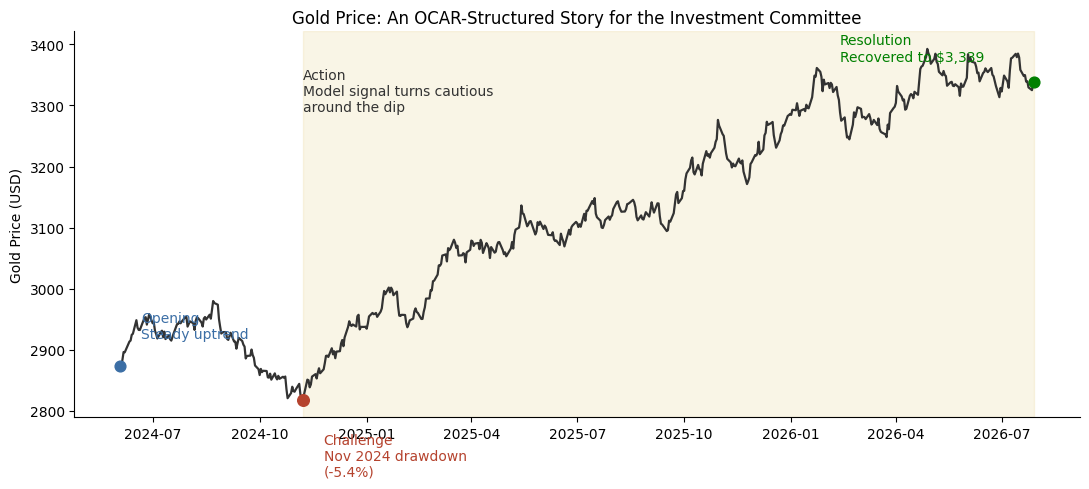

In [15]:
recent = df[df["Date"] >= "2024-06-01"].copy().reset_index(drop=True)

roll_max = recent["Price_USD"].cummax()
drawdown = (recent["Price_USD"] - roll_max) / roll_max
challenge_idx = drawdown.idxmin()
challenge_date = recent.loc[challenge_idx, "Date"]
challenge_price = recent.loc[challenge_idx, "Price_USD"]
resolution_price = recent["Price_USD"].iloc[-1]
resolution_date = recent["Date"].iloc[-1]
opening_price = recent["Price_USD"].iloc[0]
opening_date = recent["Date"].iloc[0]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(recent["Date"], recent["Price_USD"], color=CHARCOAL, linewidth=1.6)

ax.scatter([opening_date], [opening_price], color=BLUE, zorder=5, s=60)
ax.annotate("Opening\nSteady uptrend", (opening_date, opening_price),
            xytext=(15, 20), textcoords="offset points", fontsize=10, color=BLUE)

ax.scatter([challenge_date], [challenge_price], color=RED, zorder=5, s=70)
ax.annotate(f"Challenge\n{challenge_date.strftime('%b %Y')} drawdown\n({drawdown.min():.1%})",
            (challenge_date, challenge_price), xytext=(15, -55), textcoords="offset points",
            fontsize=10, color=RED)

ax.axvspan(challenge_date, resolution_date, color=GOLD, alpha=0.12)
ax.annotate("Action\nModel signal turns cautious\naround the dip",
            (challenge_date, recent["Price_USD"].max() * 0.97), fontsize=10, color=CHARCOAL)

ax.scatter([resolution_date], [resolution_price], color="green", zorder=5, s=60)
ax.annotate(f"Resolution\nRecovered to ${resolution_price:,.0f}", (resolution_date, resolution_price),
            xytext=(-140, 15), textcoords="offset points", fontsize=10, color="green")

ax.set_title("Gold Price: An OCAR-Structured Story for the Investment Committee")
ax.set_ylabel("Gold Price (USD)")
plt.tight_layout()
plt.show()

**Notice what changed** — the underlying numbers are identical to the plain line chart above, but the OCAR annotations turn it into a story a non-technical committee member can follow in ten seconds: *things were fine, then a dip happened, the model flagged it, and price recovered.* That is the exact skill described in lecture as translating "raw numerical predictions into a structured story arc that stakeholders can readily digest."

## Decluttering & Small Multiples: *"How much can one chart say?"*
The Investment Committee has four questions: What's happening to price? The dollar? Inflation? Interest rates? A tempting shortcut is to cram all four onto one chart with several y-axes. Let's build that chart — and then see why lecture warns against it.

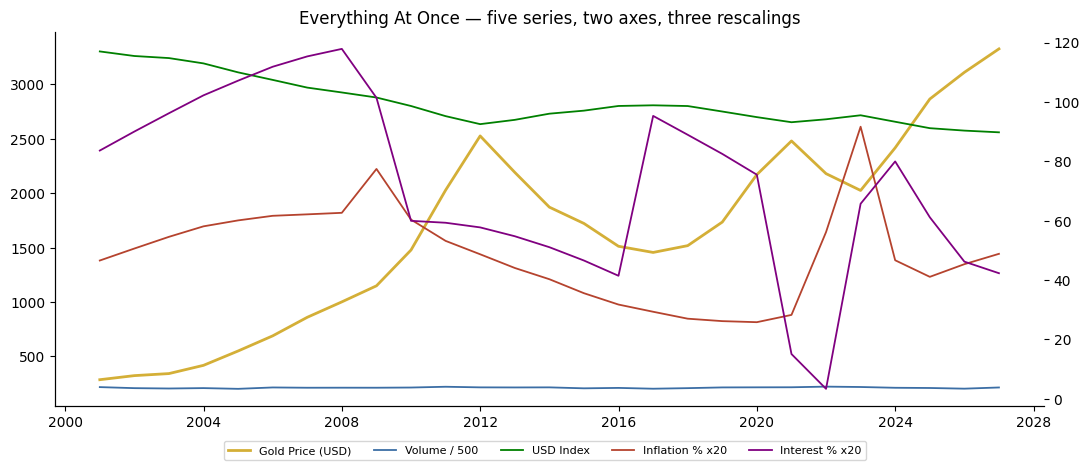

In [16]:
yearly = df.set_index("Date").resample("YE").mean(numeric_only=True)

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax2 = ax1.twinx()
ax1.plot(yearly.index, yearly["Price_USD"], color=GOLD, linewidth=2, label="Gold Price (USD)")
ax1.plot(yearly.index, yearly["Volume"] / 500, color=BLUE, linewidth=1.3, label="Volume / 500")
ax2.plot(yearly.index, yearly["USD_Index"], color="green", linewidth=1.3, label="USD Index")
ax2.plot(yearly.index, yearly["Inflation_Rate"] * 20, color=RED, linewidth=1.3, label="Inflation % x20")
ax2.plot(yearly.index, yearly["Interest_Rate"] * 20, color="purple", linewidth=1.3, label="Interest % x20")
ax1.set_title("Everything At Once — five series, two axes, three rescalings")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

This chart is honestly hard to read — two y-axes with different units, and two series artificially multiplied by 20 just to make them visible. A committee member has to hold five rescaled meanings in their head at once. This is the **cognitive overload** the lecture warns about.

The fix isn't to remove information — it's **small multiples**: the same four variables, each on its own natural scale, arranged so the eye can compare shapes side by side.

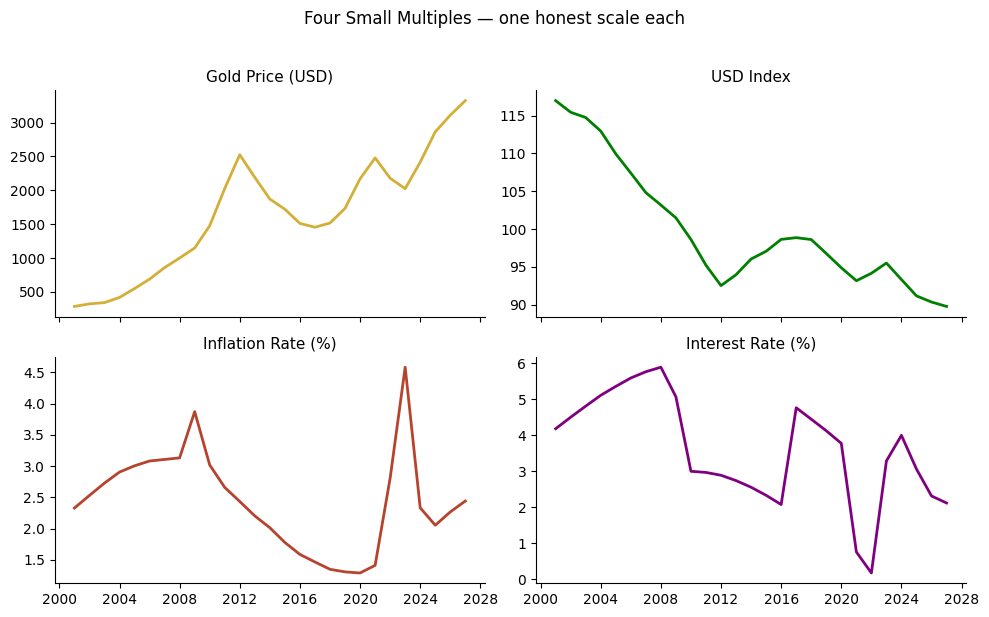

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
panels = [
    ("Price_USD", "Gold Price (USD)", GOLD),
    ("USD_Index", "USD Index", "green"),
    ("Inflation_Rate", "Inflation Rate (%)", RED),
    ("Interest_Rate", "Interest Rate (%)", "purple"),
]
for ax, (col, title, color) in zip(axes.flat, panels):
    ax.plot(yearly.index, yearly[col], color=color, linewidth=2)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("Four Small Multiples — one honest scale each", y=1.02)
plt.tight_layout()
plt.show()

**No information was lost** — every series from the cluttered chart is still here — but nobody has to mentally divide by 20 or track a second axis anymore. This is the practical answer to MCQ 4 from lecture: small multiples build comprehension progressively, one honest panel at a time, instead of demanding it all at once.

## An Isotype Graph: Making a Number Memorable
A committee member won't remember "average price rose from \$385 to \$3,188." They *will* remember a picture of a handful of gold bars growing into a stack. That's the isotype technique from lecture: replace a plain bar with **repeated copies of a recognizable icon**, where each icon represents a fixed, scaled quantity — here, one bar icon = \$250 of average price.

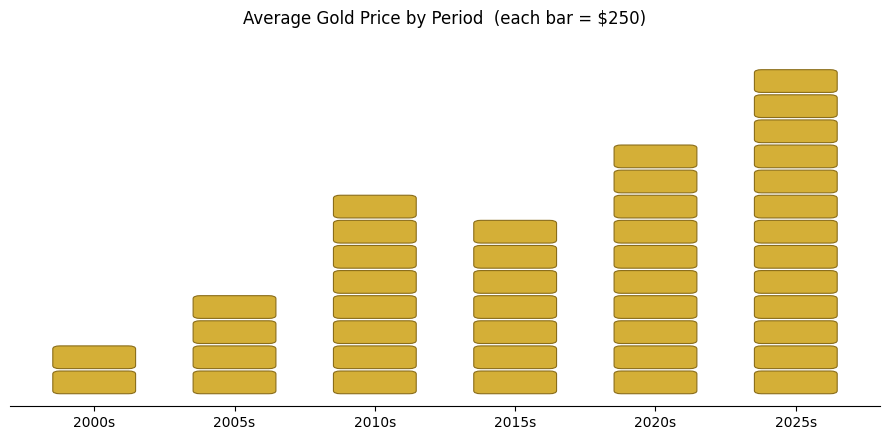

In [18]:
ICON_VALUE = 250  # one icon = $250 of average price
avg_by_period = df.groupby("_period")["Price_USD"].mean()

def draw_gold_bar(ax, x, y, w=0.55, h=0.34):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 linewidth=0.8, edgecolor="#8a6d1a", facecolor=GOLD))

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (period, val) in enumerate(avg_by_period.items()):
    n_icons = round(val / ICON_VALUE)
    for j in range(n_icons):
        draw_gold_bar(ax, i, j * 0.42)

ax.set_xlim(-0.6, len(avg_by_period) - 0.4)
ax.set_ylim(-0.4, avg_by_period.max() / ICON_VALUE * 0.42 + 0.5)
ax.set_xticks(range(len(avg_by_period)))
ax.set_xticklabels(avg_by_period.index)
ax.set_yticks([])
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.set_title(f"Average Gold Price by Period  (each bar = ${ICON_VALUE})")
plt.tight_layout()
plt.show()

**This directly answers MCQ 5 from lecture:** the visual memorability doesn't come from a fancier chart type — it comes from replacing an abstract bar height with a *countable, scaled icon* that a viewer can literally count and remember.

## Explainable AI (XAI): *"Why did the model say that?"*
Even a mediocre model (our ≈55% accuracy) is more trustworthy to a committee once they can see **which inputs pushed it toward "Up"**. This is the lecture's XAI idea — feature importance rankings turn a black box into something a human can audit, question, and hold accountable.

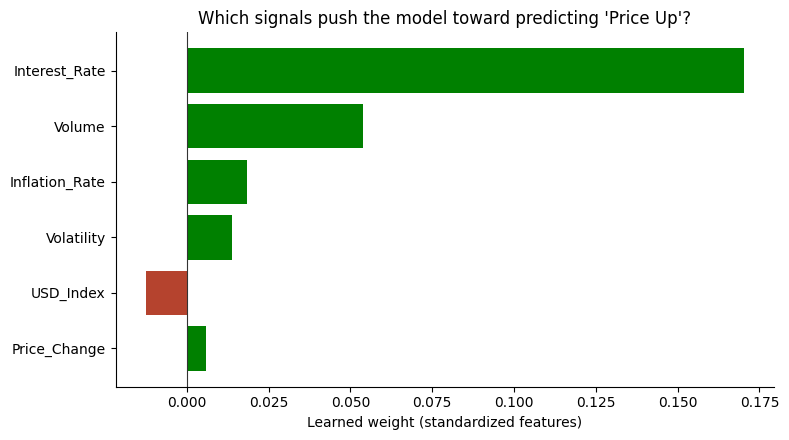

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = np.argsort(np.abs(w))
colors = ["green" if w[i] > 0 else RED for i in order]
ax.barh(np.array(feat_cols)[order], w[order], color=colors)
ax.axvline(0, color=CHARCOAL, linewidth=0.8)
ax.set_xlabel("Learned weight (standardized features)")
ax.set_title("Which signals push the model toward predicting 'Price Up'?")
plt.tight_layout()
plt.show()

**Green bars** push the prediction toward "price rises tomorrow"; **red bars** push it toward "price falls." Now the committee isn't just told *Up* or *Down* — they can see, for example, whether the model is leaning on interest-rate movements or on recent volatility, and can bring their own judgment to bear on whether they trust that reasoning for tomorrow's market. This is Explainable AI doing its job: **the AI should not only provide answers, it should explain them visually.**

## Wrap-Up: Closing the AI-Decision Gap

Trace back through what you built, and match it to the lecture:

1. **Data Collection** — missing-value heatmap & histogram → *assessed data quality*
2. **Exploratory Analysis** — scatter & box plots → *discovered patterns* (gold vs. dollar strength)
3. **Model Training** — a real loss curve → *monitored learning*
4. **Model Evaluation** — confusion matrix & ROC curve → *measured performance*, and exposed the **AI-Decision Gap**
5. **OCAR storytelling** — turned a plain line chart into a decision-ready narrative
6. **Decluttering / small multiples** — fixed a chart trying to say five things at once
7. **Isotype graph** — made a single number memorable through countable icons
8. **XAI** — made the model's reasoning visible and auditable

